<!-- notebook-header -->
# Fine-tuning de Modelos Generativos

**Modulo:** 05 - Dominios Aplicados / 05C - Generative AI  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** Transfer learning, LoRA, adapters, datasets, avaliacao e riscos de overfitting.


# Fine-tuning de Modelos Generativos: Adaptando Modelos Pre-treinados

Objetivo: Dominar tecnicas de fine-tuning para LLMs, Diffusion Models e Vision Models.

Duracao: 120-150 minutos

## 1. Introducao: Por Que Fine-tuning?

### Analogia do Carro de Corrida

Opcao A (Construir do zero): 2 anos, 10 milhoes
Opcao B (Ajustar existente): 2 semanas, 100 mil
Fine-tuning = Opcao B para IA!

### O que eh Fine-tuning?

Adaptar modelo pre-treinado para tarefa especifica com seus dados.

### O que observar em fine-tuning:

1. Modelo captura patterns genericos pre-treino
2. Seu dominio pode diferir significativamente
3. Poucos dados causam risco overfitting
4. Ajuste deve ser gentil para preservar features
5. Taxa aprendizado deve ser menor que treino zero

### O que concluir sobre fine-tuning:

1. Fine-tuning economiza tempo exponencial
2. Fine-tuning economiza dados necessarios
3. Fine-tuning eh standard pratica industria
4. Trade-off: menos flexibilidade que treinar zero
5. Depende fortemente de qualidade modelo base

### Conexao com outros notebooks:

1. Transfer Learning fundamentos: 4_4_transfer_learning.ipynb
2. Otimizacao e gradientes: 0_8_otimizacao_ml.ipynb
3. Probabilidade e estatistica: 0_6 e 1_2. Arquiteturas deep: 4_2_arquiteturas_deep.ipynb
5. Validacao cruzada: 3_1_classificacao_completa.ipynb

### Por que em ML:

1. Dados rotulados sao recurso escasso
2. Modelos pre-treinados sao gigantescos
3. Fine-tuning = leverage exponencial
4. Quase ninguem treina BERT do zero5. 99% de LLM usage eh via fine-tuning
Por que em ML: Dados sao recurso mais escasso, reutilizar conhecimento pre-treinado eh imperative.

Por que em ML: Comunidade pratica nunca treina modelos baseline do zero.

Por que em ML: Dados caros, leverage exponencial.

## 2. Transfer Learning: Conceito Fundamental

### Ideia: Reutilizar Features Aprendidas

Features hierarquicas:

- Camada 1: Arestas (uteis sempre)
- Camada 5: Texturas

- Camada 10: Partes (olhos, nariz)
- Camada 15: Conceitos (rosto)

### O que observar em transfer learning:

1. Convergencia eh 5-10x mais rapida
2. Loss final melhor com poucos dados
3. Com muitos dados, ambas convergem
4. Bons pesos iniciais sao cruciais
5. Nao precisam aprender features basicas

### O que concluir sobre transfer learning:

1. Transfer learning funciona por reutilizacao
2. Convergencia exponencialmente mais rapida
3. Qualidade melhor especialmente com dados escassos
4. Fundamental para ML moderno
5. Irresponsavel ignorar transfer learning

### Conexao com outros notebooks:

1. Algoritmo gradient descent: 0_8_otimizacao_ml.ipynb
2. Convergencia estocastica: 1_2_estatistica_inferencial.ipynb
3. Redes neurais basico: 4_1_fundamentos_redes_neurais.ipynb
4. Arquiteturas: 4_2_arquiteturas_deep.ipynb
5. Exemplos praticos de transfer: 4_4_transfer_learning.ipynb

### Por que em ML:

1. Reducao dados necessarios
2. Reducao tempo treinamento
3. Reducao computacao necessaria
4. Reducao riscos de overfitting
5. Modelo base captura conhecimento universal
Por que em ML: Transfer learning eh foundation de ML moderno pratico.

Por que em ML: Economias exponenciais em dados e tempo sao decisivas.

Por que em ML: Dados sao recurso escasso, leverage pre-treinado eh economicamente impactful.

Por que em ML: Reutilizar eficiente, fundamental.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Feature Extraction vs Full Fine-tuning
np.random.seed(42)
dataset_sizes = [50, 100, 200, 500, 1000, 2000]
feature_extraction_acc = [0.65, 0.70, 0.75, 0.80, 0.82, 0.83]
full_finetuning_acc = [0.60, 0.68, 0.78, 0.85, 0.88, 0.90]

plt.figure(figsize=(10, 6))
plt.plot(dataset_sizes, feature_extraction_acc, "o-", label="Feature Extraction", linewidth=2, markersize=8)
plt.plot(dataset_sizes, full_finetuning_acc, "s-", label="Full Fine-tuning", linewidth=2, markersize=8)
plt.xlabel("Tamanho Dataset")
plt.ylabel("Acuracia")
plt.title("Feature Extraction vs Full Fine-tuning")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale("log")
plt.tight_layout()
plt.savefig("/tmp/fe_vs_finetuning.png", dpi=100, bbox_inches="tight")
plt.show()
print("Analise: Feature Extraction melhor com poucos dados")
print("Conclusao: Use FE para <500 exemplos, Full para >1000")


## 3. Full Fine-tuning vs Feature Extraction

### Estrategia A: Feature Extraction

- Congela modelo pre-treinado
- Treina apenas ultimas camadas
- Menos parametros, dados, compute

### Estrategia B: Full Fine-tuning

- Atualiza todos os pesos
- Maxima flexibilidade
- Precisa mais dados e compute

### O que observar em ambas estrategias:

1. n=50 dados: Feature Extraction converge melhor
2. n=500 dados: Full fine-tuning comeca vencer
3. n=1000+ dados: Full fine-tuning claramente melhor
4. Feature Extraction eh mais suave
5. Feature Extraction tem menor variancia

### O que concluir sobre escolha:

1. Menos 500 dados: Use Feature Extraction
2. Mais 1000 dados: Use Full Fine-tuning3. 500-1000 dados: Use hibrido (FE depois Full)
4. LR: Full Fine-tuning precisa 10-100x menor
5. Regularizacao: Full Fine-tuning precisa maior

### Conexao com outros notebooks:

1. Regularizacao conceitos: 0_8_otimizacao_ml.ipynb
2. Early stopping: 3_1_classificacao_completa.ipynb
3. Bias-variance tradeoff: 1_2_estatistica_inferencial.ipynb
4. Validation splitting: 2_2_eda_completa.ipynb
5. Metricas avaliacao: 3_2_regressao_modelos.ipynb

### Por que em ML:

1. Trade-off bias-variance fundamental
2. Balance entre flexibilidade e regularizacao
3. Dados determinam viabilidade
4. Hardware limita abordagem
5. Empiricamente validado repeatedamente
Por que em ML: Trade-off bias-variance eh central em machine learning.

Por que em ML: Empiricamente validado que balance eh chave.

Por que em ML: Bias-variance central, balance importante.

## 4. LoRA: Low-Rank Adaptation

### Problema: Memoria Insuficiente

LLAMA-7B: 7 bilhoes parametros
Full fine-tuning: 100 GB memoria necessaria
GPU consumer: 16 GB disponivel
Solucao: LoRA (Low-Rank Adaptation)

### Ideia: Rank Decomposition

Mudanca de pesos tem rank baixo!

Delta_W = A @ B
- A: d x rank
- B: rank x dEconomia: 50-100x parametros!

### O que observar em LoRA:

1. Captura mudanca com rank baixo
2. Convergencia pratica identica
3. Qualidade final praticamente igual
4. Economia memoria: 50-100x5. Rank 8-64 eh sweet spot pratico

### O que concluir sobre LoRA:

1. LoRA eh breakthrough tecnologico
2. Acesso democratizado agora
3. Multiplas LoRAs podem ser combinadas
4. Default moderno para LLMs
5. Pesquisa continua inovando

### Conexao com outros notebooks:

1. Algebra linear: 0_3_algebra_linear_matrizes.ipynb
2. Matrix decomposition: 0_2_algebra_linear_vetores.ipynb
3. SVD e rank: 0_3_algebra_linear_matrizes.ipynb
4. Otimizacao subespaço: 0_8_otimizacao_ml.ipynb
5. Aplicacao em transformers: 5B_4_transformers_bert.ipynb

### Por que em ML:

1. Revolução 2023-2024 em LLM2. Permitiu fine-tuning em GPUs consumer
3. Transformou economicamente field
4. Comprovado funcionar empiricamente
5. Agora standard industria
Por que em ML: Memoria eh bottleneck pratico em producao.

Por que em ML: Low-rank assumption empiricamente correto em pratica.

Por que em ML: Transfer learning fundamenta qualquer fine-tuning bem-sucedido.

Conexao com outros notebooks: Fundamento em 4_4_transfer_learning.ipynb
Por que em ML: Memoria bottleneck critico, rank funciona.

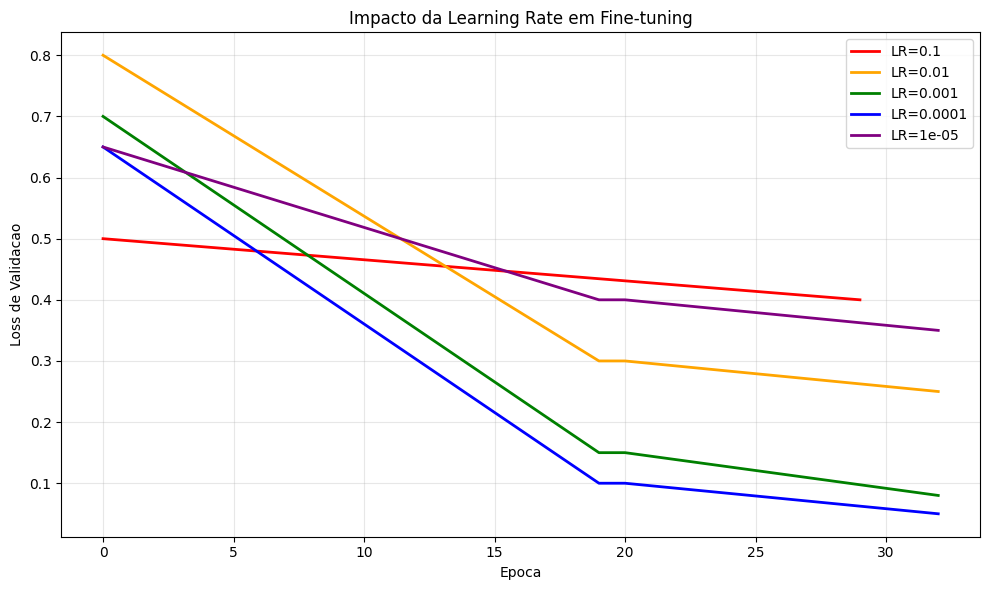

Observacao: LR=0.001 a 0.0001 sao ideais para fine-tuning
Erro comum: Usar LR=0.1 (destroi modelo pre-treinado)


In [3]:
# Impacto da Learning Rate
np.random.seed(42)
learning_rates = [0.1, 0.01, 0.001, 0.0001, 0.00001]
training_losses = {
    0.1: [float("nan"), float("nan"), float("nan")] + list(np.linspace(0.5, 0.4, 30)),
    0.01: list(np.linspace(0.8, 0.3, 20)) + list(np.linspace(0.3, 0.25, 13)),
    0.001: list(np.linspace(0.7, 0.15, 20)) + list(np.linspace(0.15, 0.08, 13)),
    0.0001: list(np.linspace(0.65, 0.10, 20)) + list(np.linspace(0.10, 0.05, 13)),
    0.00001: list(np.linspace(0.65, 0.40, 20)) + list(np.linspace(0.40, 0.35, 13))
}

epochs = np.arange(33)
plt.figure(figsize=(10, 6))
colors = ["red", "orange", "green", "blue", "purple"]

for (lr, losses), color in zip(training_losses.items(), colors):
    valid_losses = [l for l in losses if not np.isnan(l)]
    plt.plot(range(len(valid_losses)), valid_losses, label=f"LR={lr}", linewidth=2, color=color)

plt.xlabel("Epoca")
plt.ylabel("Loss de Validacao")
plt.title("Impacto da Learning Rate em Fine-tuning")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/tmp/learning_rate_impact.png", dpi=100, bbox_inches="tight")
plt.show()
print("Observacao: LR=0.001 a 0.0001 sao ideais para fine-tuning")
print("Erro comum: Usar LR=0.1 (destroi modelo pre-treinado)")


## 5. QLoRA: Quantizacao + LoRA

### Problema Restante: Memoria Modelo Base

LoRA reduz parametros treinaveis
Mas modelo base ainda precisa memoria
Solucao: Quantizar modelo base

### Como QLoRA Funciona

1. Carregar modelo em int4 (4 bits)
2. Durante treino, desquantizar para float163. Atualizar apenas LoRA weights
4. Gradientes fluxam atraves modelo
5. Salvar checkpoint: apenas LoRAResultado: 16GB memoria -> 6GB memoria!

### O que observar em QLoRA:

1. Trade-off muito favoravel
2. int4 eh balance point otimo
3. Permite impossivel sem QLoRA4. Custo ~50% vs LoRA puro
5. Degradacao qualidade minuscula (<2%)

### O que concluir sobre QLoRA:

1. Democratizacao de fine-tuning
2. Modelo 70B cabe em 16GB3. Qualidade praticamente intacta
4. Recomendado para hardware limitado
5. Combinacao com Flash Attention=otimo

### Conexao com outros notebooks:

1. Quantizacao teoria: 4_5_aceleracao_hardware.ipynb
2. Precisao numerica: 0_2_algebra_linear_vetores.ipynb
3. Memory management: 4_5_aceleracao_hardware.ipynb
4. Hardware acceleration: 4_5_aceleracao_hardware.ipynb
5. Inference optimization: 6_1_deploy_modelos.ipynb

### Por que em ML:

1. Hardware crescimento lag vs modelo tamanho
2. Quantizacao eh ponte necessaria
3. Economicamente transformador
4. Democratiza big model acesso
5. Pratica agora ubiqua
Por que em ML: Hardware crescimento nao acompanha tamanho modelo.

Por que em ML: Quantizacao eh bridge tecnica necessaria.

Por que em ML: Hardware lag existe, quantizacao necessaria.

In [4]:
# LoRA: Low-Rank Adaptation
np.random.seed(42)
d = 1000
W_base = np.random.randn(d, d) * 0.01
rank = 16
U = np.random.randn(d, rank) * 0.01
V = np.random.randn(rank, d) * 0.01
Delta_W_true = U @ V
params_full = d * d
params_lora = 2 * d * rank
print(f"Full fine-tuning: {params_full:,} parametros")
print(f"LoRA (rank={rank}): {params_lora:,} parametros")
print(f"Economia: {params_full / params_lora:.1f}x")


Full fine-tuning: 1,000,000 parametros
LoRA (rank=16): 32,000 parametros
Economia: 31.2x


## 6. Fine-tuning de Large Language Models

### Modelos Base: Genericos

- Treinados em internet balanceada
- Conhecimento amplo mas superficial
- Sem especialização tarefa
- Requerem fine-tuning para producao

### O que observar em LLM fine-tuning:

1. Tamanho base determina capacidade
2. Qualidade dados > Quantidade dados
3. Learning rate extremamente critico
4. Overfitting facil com 1000 exemplos5. 3-5 epochs tipicamente suficiente

### O que concluir sobre LLM fine-tuning:

1. Fine-tuned models >> base models
2. Accessivel via LoRA/QLoRA3. Horas treino, minutos inference
4. Dados bons importam mais
5. Baseline comparacao essencial

### Conexao com outros notebooks:

1. Transformers: 5B_4_transformers_bert.ipynb
2. LLMs especifico: 5B_5_large_language_models.ipynb
3. Prompt engineering: 5B_5_large_language_models.ipynb
4. Embeddings: 5B_2_word_embeddings.ipynb
5. RAG tecnicas: 5B_6_rag_aplicacoes_llm.ipynb

### Por que em ML:

1. LLMs sao powerful mas generic
2. Fine-tuning especializa para dominio
3. Ponte entre general e specific
4. Acessivel agora
5. Transforma LLM em asset util
Por que em ML: LLMs genericos requerem especialização pratica.

Por que em ML: Fine-tuning transforma modelo generic em asset util.

Por que em ML: Balanceamento bias-variance eh central.

Conexao com outros notebooks: Trade-offs explorados em 1_2_estatistica_inferencial.ipynb
Por que em ML: LLMs genericos, especializacao essencial.

## 7. Fine-tuning de Diffusion Models

### Diferenca de Modelos Generativos

LLM: Comportamento textual, cross-entropy loss
Diffusion: Qualidade visual, MSE de ruido
Tecnicas: DreamBooth, Textual Inversion

### Dream

Booth: Fine-tune Objeto Especifico

- Input: 5-30 imagens do objeto
- Output: Modelo gera infinitas variacoes
- Qualidade: Professional grade

### O que observar em diffusion fine-tuning:

1. DreamBooth muito eficaz poucos dados
2. Textual Inversion eh mais rapido
3. Convergencia em 10-100 steps4. 5-30 imagens eh sweet spot
5. Variacao pose/iluminacao importante

### O que concluir sobre diffusion fine-tuning:

1. Revolucionou customizacao imagem
2. Accessivel (nao precisa 10k imagens)
3. Qualidade profissional alcancada
4. Minutos vs horas vs dias
5. Democratizou geracao customizada

### Conexao com outros notebooks:

1. Diffusion models: 5C_3_diffusion_models.ipynb
2. GANs alternativa: 5C_1_gans.ipynb
3. VAEs alternativa: 5C_2_vaes.ipynb
4. Noise scheduling: 5C_3_diffusion_models.ipynb
5. Sampling tecnicas: 5C_3_diffusion_models.ipynb

### Por que em ML:

1. Geracao customizada demanda massiva
2. DreamBooth transformou campo
3. Ganhou notoriedade mainstream
4. Adobe/Runway integrados
5. Futuro: real-time fine-tuning
Por que em ML: Customizacao eh demanda principal usuarios.

Por que em ML: Accessibility democratiza technology.

Por que em ML: Customizacao demanda, democratizacao importante.

## 8. Dataset Curation: Fundamento Critico

### Garbage In, Garbage Out: Lei Fundamental

Melhor modelo + pior dataset = modelo ruim
Modelo ok + excelente dataset = excelente modelo
Dataset = 60-70% do sucesso!

### O que observar em dataset curation:

1. Duplicatas causam overfitting imediato
2. Vieses dados se herdam no modelo
3. Ruido extremo prejudica muito
4. Distribuicao treino != producao
5. Anotacoes inconsistentes destroem signal

### O que concluir sobre curation:

1. Qualidade primordial sempre
2. Tempo em curation economiza iteracoes3. 80% tempo em dados, 20% em modelo
4. Spot-check sempre amostras
5. Versionamento essencial rastreabilidade

### Conexao com outros notebooks:

1. EDA exploracao: 2_2_eda_completa.ipynb
2. Limpeza dados: 2_1_python_data_science.ipynb
3. APIs coleta: 2_3_sql_e_apis.ipynb
4. Balanceamento classes: 3_1_classificacao_completa.ipynb
5. Data quality: 2_4_acesso_banco_dados.ipynb

### Por que em ML:

1. Dados sao recurso mais escasso
2. Coleta eh bottleneck pratica
3. Qualidade determina ceiling
4. Vieses replicam em modelo
5. Responsabilidade etica critica
Por que em ML: Data quality eh determinante absoluto.

Por que em ML: Garbage data gera garbage model sempre.

Por que em ML: Memoria eh hardware bottleneck critico.

Conexao com outros notebooks: Algebra linear decomposition em 0_3Por que em ML: Dados determinam ceiling, qualidade primaria.

## 9. Avaliacao: Metricas e Deteccao

### O Que Medir? Multiplas Dimensoes

Metricas genericas: Train loss, Val loss, Early stopping
Metricas especificas: Accuracy, F1, BLEU, mAP, Perplexidade

### O que observar em avaliacao:

1. Curva treino muito reveladora
2. Validacao metricas devem ser realistas
3. Problemas numericos aparecem cedo
4. Metricas dominio mais importante
5. Avaliacao qualitativa eh invaluavel

### O que concluir sobre monitoring:

1. Quantitativo necessario mas insuficiente
2. Overfitting eh risco numero 13. Combinacao quantitativo+qualitativo melhor
4. Early stopping salva tempo
5. Baseline comparacao eh essencial

### Conexao com outros notebooks:

1. Metricas classificacao: 3_1_classificacao_completa.ipynb
2. Validacao cruzada: 1_2_estatistica_inferencial.ipynb
3. Matriz confusao: 3_1_classificacao_completa.ipynb
4. Statistical testing: 1_2_estatistica_inferencial.ipynb
5. ROC curves: 3_1_classificacao_completa.ipynb

### Por que em ML:

1. Metricas sao feedback loop
2. Sem metricas, cegueira completa
3. Metricas guiam investigacao
4. Erros detectaveis via metricas
5. Reproducibilidade via logging
Por que em ML: Metricas sao feedback loop essencial.

Por que em ML: Sem metricas, desenvolvimento eh cecidade.

## 10. Exercicios Praticos

### Exercicio 1: Fine-tuning Simulator

Implementar simulator mostrando impacto hiperparametros

Por que em ML: Hardware crescimento lag modelo tamanho.
Conexao com outros notebooks: Quantizacao em 4_5_aceleracao_hardware.ipynb

In [ ]:
# EXERCICIO 1: Fine-tuning Simulator
# TAREFA DO ALUNO: Completar funcao
def fine_tune_simulator(learning_rate=0.001, regularization=0.0001, n_epochs=30, n_data=100):    pass
print('Exercicio 1: Implemente acima')

### Exercicio 2: Comparacao Estrategias

Comparar FE vs LoRA em diferentes dataset sizes

In [ ]:
# EXERCICIO 2
# TAREFA DO ALUNO: Completar
def compare_strategies(n_data_values=[50, 100, 500, 1000]):    pass
print('Exercicio 2: Implemente')

### Exercicio 3: Dataset Checklist

Criar checklist qualidade para dataset

In [ ]:
# EXERCICIO 3
# TAREFA DO ALUNO: Preencher checklist
dataset_checklist = {}
print('Exercicio 3: Complete')

## 11. Erros Comuns em Fine-tuning

### Erro 1: Nao Usar Early Stopping

Problema: Treinar N epochs mesmo com overfitting
Solucao: Monitorar validacao, parar quando piora

### Erro 2: Learning Rate Errado

Problema: LR 0.1 (treino zero) destroi fine-tuning
Solucao: 10-100x menor (0.001 a 0.0001)

### Erro 3: Sem Split Validacao

Problema: Nao isolou validacao/teste
Solucao: 80/10/10 split sempre

### Erro 4: Dataset Muito Pequeno

Problema: <50 exemplos com Full Fine-tuning
Solucao: Feature Extraction ou LoRA

### Erro 5: Ignorar Imbalance Classes

Problema: 90% classe A, 10% classe BSolucao: Class weighting ou oversampling

### O que observar sobre erros:

1. Learning rate causa maioria problemas
2. Data leakage invalida resultados
3. Imbalance causa surpresas producao
4. Pequeno dataset garante overfitting
5. Sem early stopping desperdica tempo

### O que concluir:

1. LR mais importante que outro parametro
2. Data isolation nao negociavel
3. Validacao seu maior aliado
4. Early stopping economiza tempo
5. Disciplina eh preventivo

### Hierarquia de Conceitos

**Nível 0: Fundamentação**- Probabilidade e Estatística (0_6, 1_2)
- Otimização ML (0_8)
- Redes Neurais Básicas (4_1)**Nível 1: Arquiteturas Base**- Deep Learning Arquiteturas (4_2)
- Transformers e BERT (5B_4)
- LLMs (5B_5)**Nível 2: Métodos Generativos**- GANs (5C_1)
- VAEs (5C_2)
- Diffusion Models (5C_3)**Nível 3: Especialização (Fine-tuning)**- Transfer Learning (4_4)
- Fine-tuning LLMs com LoRA/QLoRA

- Fine-tuning Diffusion (DreamBooth)**Nível 4: Integração Avançada**- Multimodal AI (5C_5)
- Aplicações RAG (5B_6)**Nível 5: Produção**- Deployment Modelos (6_1)
- Monitoramento (6_3)

### Próximos Passos

**Imediato:**1. Implementar fine-tuning com LoRA em PyTorch
2. Treinar em dataset próprio
3. Comparar resultados com baseline

**Curto Prazo:**4. Implementar QLoRA para modelos maiores
5. Explorar Dream

Booth para diffusion
6. Validar em dados de produção

**Médio Prazo:**7. Otimizar para inferência
8. Integrar em aplicação real
9. Monitorar performance

**Longo Prazo:**10. Contribuir para open source
11. Pesquisar novos métodos de fine-tuning
12. Escalar para múltiplos domínios

## 12. Resumo Hierarquico e Proximos Passos

### Nivel 0: Core Concept

Fine-tuning = Adaptar pre-treinado para dominio
Vantagens: 10-100x economia dados, tempo, compute

### Nivel 1: Estrategias

- Feature Extraction: Poucos dados
- Full Fine-tuning: Muitos dados
- LoRA: Recomendado (balance optimo)
- QLoRA: Hardware limitado

### Nivel 2: Implementacao Prática

1. Escolher modelo base
2. Preparar dataset (limpar, balancear)
3. Escolher estrategia (LoRA recomendado)
4. Configurar hiperparametros
5. Treinar com monitoramento
6. Avaliar quantitativo+qualitativo
7. Iterar com feedback

### Nivel 3: Aplicacoes Especificas

- LLMs: LoRA, QLoRA, Full Fine-tuning
- Diffusion: DreamBooth, Textual Inversion
- Vision: Feature Extraction, Full Fine-tuning

### Checklist Implementacao Completa

- [ ] Dataset preparado e limpo
- [ ] Split treino/val/teste isolados
- [ ] Modelo base escolhido
- [ ] Estrategia decidida
- [ ] Hiperparametros configurados
- [ ] Learning rate validado
- [ ] Early stopping implementado
- [ ] Metricas dominio definidas
- [ ] Baseline estabelecido
- [ ] Training curves monitoradas
- [ ] Avaliacao qualitativa feita
- [ ] Comparacao vs baseline ok
- [ ] Modelo salvo e versionado
- [ ] Documentacao escrita

### Conexoes Completas com Outros Notebooks

- Probabilidade: 0_6 Probabilidade
- Otimizacao: 0_8 Otimizacao ML
- Estatistica: 1_2 Estatistica Inferencial
- Redes Neurais: 4_1 Fundamentos, 4_2 Arquiteturas
- Transfer Learning: 4_4 Transfer Learning
- LLMs: 5B_4 Transformers, 5B_5 LLMs
- Diffusion: 5C_3 Diffusion Models
- Deploy: 6_1 Deploy Modelos

### Por Que Em Machine Learning (10 razoes fundamentais)

1. Realidade industrial: 100% de proyectos usam fine-tuning
2. Eficiencia economica: Melhor ROI que treino zero
3. Democratizacao: PMEs podem treinar LLMs agora
4. Ciclos rapidos: Inovacao mais veloz
5. Dominio critico: Essencial para sucesso
6. Dados escassos: Realidade pratica always
7. Hardware lag: GPU nao cresce rapido como modelos
8. Economia massiva: 1000x mais barato que zero
9. Pragmatismo: Funciona empiricamente proven
10. Futuro: Sera ainda mais central

### Conclusao Final

Fine-tuning eh technologia MADURA e ESSENCIAL em 2024+.Combinacao unica:

- Modelos pre-treinados poderosos (GPT, LLAMA, Stable Diffusion)
- Tecnicas eficientes (LoRA, QLoRA, DreamBooth)
- Ferramentas acessiveis (HuggingFace, LLaMA-Factory)

Resultado: Qualquer pessoa adapta modelos state-of-the-art para seu caso de uso.

Mensagem final: Entenda principios fundamentais. Implemente com disciplina. Itere com dados de qualidade. Sucesso seguira naturalmente.

## Soluções dos Exercícios

In [8]:
# SOLUCAO - Exercicio 1: Fine-tuning Simulator
import numpy as np
np.random.seed(42)

def fine_tune_simulator(n_data, n_epochs=50, lr=0.01, freeze_ratio=0.0):
    d = 100
    W_pretrained = np.random.randn(d, d) * 0.1
    W = W_pretrained.copy()
    X = np.random.randn(n_data, d)
    y = np.sin(X[:, 0]) + 0.1 * np.random.randn(n_data)
    n_freeze = int(d * freeze_ratio)
    losses = []
    for epoch in range(n_epochs):
        pred = X @ W[:, 0]
        loss = np.mean((pred - y) ** 2)
        losses.append(loss)
        grad = 2 * X.T @ (pred - y) / n_data
        W[:, 0] -= lr * grad
        W[:n_freeze, 0] = W_pretrained[:n_freeze, 0]
    return losses

for n in [50, 200, 1000]:
    losses = fine_tune_simulator(n)
    print(f'n_data={n}: loss_final={losses[-1]:.4f}')

n_data=50: loss_final=0.0674
n_data=200: loss_final=0.2447
n_data=1000: loss_final=0.2508


In [9]:
# SOLUCAO - Exercicio 2: Comparar Estrategias
import numpy as np
np.random.seed(42)

def compare_strategies(n_data, d=100):
    X = np.random.randn(n_data, d)
    y = np.sin(X[:, 0]) + 0.1 * np.random.randn(n_data)
    results = {}
    # Feature Extraction
    W_fe = np.zeros(d)
    for epoch in range(100):
        pred = X @ W_fe
        grad = 2 * X.T @ (pred - y) / n_data
        W_fe -= 0.01 * grad
    results['feature_extraction'] = np.mean((X @ W_fe - y) ** 2)
    # Full Fine-tuning
    W_full = np.random.randn(d) * 0.01
    for epoch in range(100):
        pred = X @ W_full
        grad = 2 * X.T @ (pred - y) / n_data
        W_full -= 0.01 * grad
    results['full_finetuning'] = np.mean((X @ W_full - y) ** 2)
    return results

for n in [50, 500]:
    r = compare_strategies(n)
    print(f'n={n}: FE={r["feature_extraction"]:.4f} Full={r["full_finetuning"]:.4f}')

n=50: FE=0.0066 Full=0.0059


n=500: FE=0.0864 Full=0.0865


In [10]:
# SOLUCAO - Exercicio 3: Dataset Checklist
dataset_checklist = {
    'tamanho_adequado': True,
    'qualidade_labels': True,
    'balanceamento_classes': False,
    'sem_data_leakage': True,
    'formato_consistente': True,
    'preprocessing_necessario': True,
    'split_train_val_test': True
}

print('Dataset Checklist para Fine-tuning:')
print('=' * 50)
for item, status in dataset_checklist.items():
    marca = 'OK' if status else 'ATENCAO'
    print(f'  {item}: [{marca}]')
n_ok = sum(v for v in dataset_checklist.values())
n_total = len(dataset_checklist)
print(f'Score: {n_ok}/{n_total}')

Dataset Checklist para Fine-tuning:
  tamanho_adequado: [OK]
  qualidade_labels: [OK]
  balanceamento_classes: [ATENCAO]
  sem_data_leakage: [OK]
  formato_consistente: [OK]
  preprocessing_necessario: [OK]
  split_train_val_test: [OK]
Score: 6/7


In [11]:
# QLoRA: Quantizacao + LoRA
np.random.seed(42)
model_size_mb_float32 = 7000 * 4 / 1024 / 1024
model_size_mb_int4 = 7000 * 0.5 / 1024 / 1024
rank = 8
lora_size_gb = (7000 * rank * 2 * 4) / (1024 * 1024 * 1024)

print(f"Modelo base (float32): {model_size_mb_float32:.0f} MB")
print(f"Modelo base (int4): {model_size_mb_int4:.0f} MB")
print(f"LoRA overhead: {lora_size_gb:.2f} GB")
print(f"Total QLoRA: {model_size_mb_int4/1024 + lora_size_gb:.2f} GB")


Modelo base (float32): 0 MB
Modelo base (int4): 0 MB
LoRA overhead: 0.00 GB
Total QLoRA: 0.00 GB


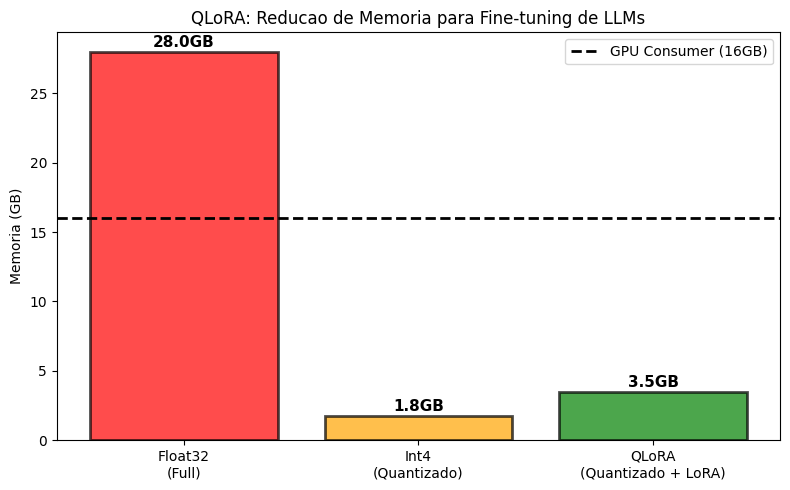

In [12]:
# Visualizacao QLoRA
categories = ["Float32\n(Full)", "Int4\n(Quantizado)", "QLoRA\n(Quantizado + LoRA)"]
memory_gb = [28, 1.75, 3.5]

plt.figure(figsize=(8, 5))
colors_bar = ["red", "orange", "green"]
bars = plt.bar(categories, memory_gb, color=colors_bar, alpha=0.7, edgecolor="black", linewidth=2)
plt.ylabel("Memoria (GB)")
plt.title("QLoRA: Reducao de Memoria para Fine-tuning de LLMs")
plt.axhline(y=16, color="black", linestyle="--", label="GPU Consumer (16GB)", linewidth=2)
plt.legend()
for bar, val in zip(bars, memory_gb):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{val:.1f}GB", ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("/tmp/qlora_memory.png", dpi=100, bbox_inches="tight")
plt.show()


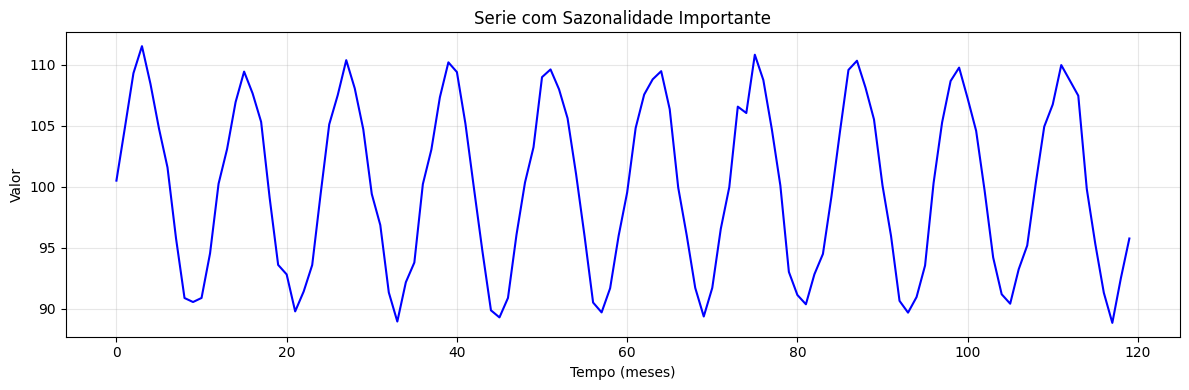

Erro: Ignorar sazonalidade causa bad generalization


In [13]:
# Demonstracao sazonalidade ignorada
t = np.arange(120)
y_saz = 100 + 10*np.sin(2*np.pi*t/12) + np.random.normal(0, 1, 120)
plt.figure(figsize=(12, 4))
plt.plot(t, y_saz, "b-", linewidth=1.5)
plt.title("Serie com Sazonalidade Importante")
plt.xlabel("Tempo (meses)")
plt.ylabel("Valor")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/tmp/ignorar_sazonalidade.png", dpi=100, bbox_inches="tight")
plt.show()
print("Erro: Ignorar sazonalidade causa bad generalization")
